# Implementing Maximum Likelihood Estimation (MLE) for Different Distributions

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Maximum Likelihood Estimation for different distributions
- Understand the likelihood function and log-likelihood
- Estimate parameters using MLE for Gaussian, Poisson, and Bernoulli distributions
- Compare MLE estimates with true parameters

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — minimizing a loss and maximizing a likelihood are the same move: MSE *is* the Gaussian log-likelihood.

**Used later in:** Course 08 (AIAT 122) — Unit 1 — cross-entropy loss, which every notebook there uses, is a negative log-likelihood.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Implementing Maximum Likelihood Estimation (MLE) for different distributions

---

## Introduction

**Maximum Likelihood Estimation (MLE)** is a method for estimating parameters of a probability distribution by maximizing the likelihood function, which measures how likely the observed data is given the parameter values.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib, scipy.stats for distributions, SciPy's optimizers, and
# pandas/sklearn to load the three REAL datasets we estimate parameters from.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar, minimize
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nImplementing Maximum Likelihood Estimation (MLE)")
print("=" * 60)


✅ Libraries imported!

Implementing Maximum Likelihood Estimation (MLE)


## Part 1: MLE for Gaussian Distribution


Part 1: MLE for Gaussian Distribution

Real measurements: mean texture of 569 tumour biopsies
 Range: 9.71 to 39.28

MLE estimates (closed form):
 μ_MLE (sample mean): 19.2896
 σ_MLE (sample std): 4.2973

MLE from numerical optimization (started far away, at μ=9.7, σ=1):
 μ_MLE: 19.2896
 σ_MLE: 4.2973
 Agreement with the formula: Δμ = 4.50e-08, Δσ = 1.38e-07

Log-likelihood at the MLE:            -1636.96
Log-likelihood at μ=22.29 (3 units off): -1775.62  <- lower, as it must be


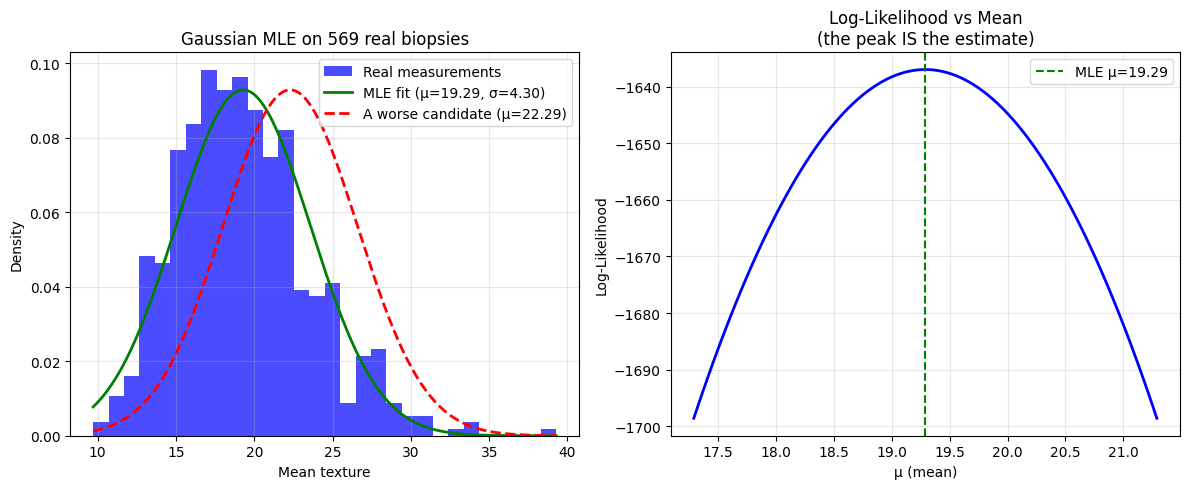


Fit check - Shapiro-Wilk normality test on the same data: p = 7.28e-08
The Normal family is a good working model here, but not a perfect one. MLE finds the
BEST Normal for this data; whether a Normal was the right shape is a separate question.

✅ MLE for Gaussian distribution implemented on real data!


In [2]:
# MLE for a Gaussian on REAL measurements: the closed-form answers (sample mean/std)
# versus SciPy's numerical optimizer. Both maximize the same log-likelihood - the optimizer
# just does not know the shortcut.
#
# Important shift from a textbook demo: with real data there is NO "true mu" to recover.
# MLE answers a different question - "which Normal makes what I observed most likely?"

print("=" * 60)
print("Part 1: MLE for Gaussian Distribution")
print("=" * 60)

# Real data: "mean texture" measured on 569 breast-tumour biopsies (the standard deviation
# of grey-scale values in each digitised tumour image).
cancer = load_breast_cancer()
data = cancer.data[:, list(cancer.feature_names).index("mean texture")]

print(f"\nReal measurements: mean texture of {len(data)} tumour biopsies")
print(f" Range: {data.min():.2f} to {data.max():.2f}")

# MLE for Gaussian: sample mean and sample std
mle_mu = np.mean(data)
mle_sigma = np.std(data, ddof=0)  # MLE uses N, not N-1

print(f"\nMLE estimates (closed form):")
print(f" μ_MLE (sample mean): {mle_mu:.4f}")
print(f" σ_MLE (sample std): {mle_sigma:.4f}")

# Negative log-likelihood function (we minimize this)
def neg_log_likelihood_gaussian(params, data):
    """Negative log-likelihood for Gaussian distribution"""
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    n = len(data)
    log_likelihood = -n * np.log(sigma * np.sqrt(2 * np.pi)) - np.sum((data - mu)**2) / (2 * sigma**2)
    return -log_likelihood  # Return negative for minimization

# Optimize using scipy, starting from a deliberately poor guess so the search has work to do
result = minimize(lambda p: neg_log_likelihood_gaussian(p, data),
                  x0=[data.min(), 1.0],
                  method='BFGS')
mle_mu_opt = result.x[0]
mle_sigma_opt = result.x[1]
print(f"\nMLE from numerical optimization (started far away, at μ={data.min():.1f}, σ=1):")
print(f" μ_MLE: {mle_mu_opt:.4f}")
print(f" σ_MLE: {mle_sigma_opt:.4f}")
print(f" Agreement with the formula: Δμ = {abs(mle_mu_opt - mle_mu):.2e}, "
      f"Δσ = {abs(mle_sigma_opt - mle_sigma):.2e}")

# A deliberately worse candidate, to show what "maximum" means
worse_mu, worse_sigma = mle_mu + 3.0, mle_sigma
ll_best = -neg_log_likelihood_gaussian([mle_mu, mle_sigma], data)
ll_worse = -neg_log_likelihood_gaussian([worse_mu, worse_sigma], data)
print(f"\nLog-likelihood at the MLE:            {ll_best:.2f}")
print(f"Log-likelihood at μ={worse_mu:.2f} (3 units off): {ll_worse:.2f}  <- lower, as it must be")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(data, bins=30, density=True, alpha=0.7, color='blue', label='Real measurements')
x = np.linspace(data.min(), data.max(), 200)
plt.plot(x, stats.norm.pdf(x, mle_mu, mle_sigma), 'g-', linewidth=2,
         label=f'MLE fit (μ={mle_mu:.2f}, σ={mle_sigma:.2f})')
plt.plot(x, stats.norm.pdf(x, worse_mu, worse_sigma), 'r--', linewidth=2,
         label=f'A worse candidate (μ={worse_mu:.2f})')
plt.xlabel('Mean texture')
plt.ylabel('Density')
plt.title('Gaussian MLE on 569 real biopsies')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
mu_range = np.linspace(mle_mu - 2, mle_mu + 2, 100)
log_likelihoods = [-neg_log_likelihood_gaussian([mu, mle_sigma], data) for mu in mu_range]
plt.plot(mu_range, log_likelihoods, 'b-', linewidth=2)
plt.axvline(mle_mu, color='g', linestyle='--', label=f'MLE μ={mle_mu:.2f}')
plt.xlabel('μ (mean)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs Mean\n(the peak IS the estimate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Honest postscript: MLE picks the best member of a family; it cannot tell you the
# family was the right choice.
print(f"\nFit check - Shapiro-Wilk normality test on the same data: p = {stats.shapiro(data).pvalue:.2e}")
print("The Normal family is a good working model here, but not a perfect one. MLE finds the")
print("BEST Normal for this data; whether a Normal was the right shape is a separate question.")

print("\n✅ MLE for Gaussian distribution implemented on real data!")


## Part 2: MLE for Poisson Distribution



Part 2: MLE for Poisson Distribution



Real data: 911 calls between 03:00 and 04:00
 Nights observed: 765
 Counts range from 1 to 20 calls per night

MLE estimate:
 λ_MLE (sample mean): 5.6418 calls per night in that hour
 λ from numerical optimization: 5.6418  (matches the sample mean)


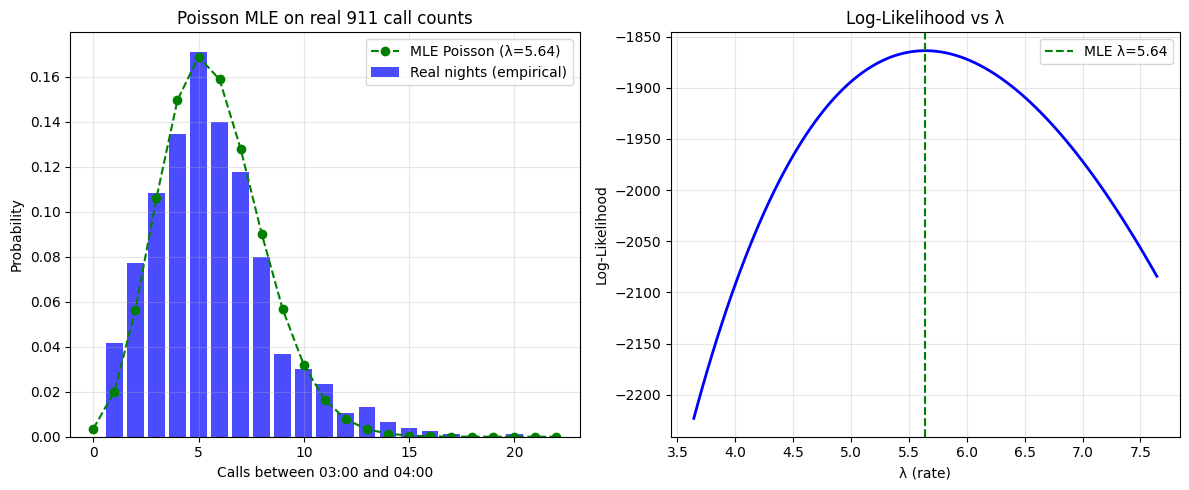


Model check - a Poisson distribution must have variance = mean:
  sample mean:     5.642
  sample variance: 8.102
  ratio: 1.44
Real call volume is somewhat OVER-dispersed - busy nights cluster (weather, holidays),
so calls are not perfectly independent. The Poisson is a useful approximation here,
not the literal truth. MLE gives the best lambda; it cannot fix the wrong family.

✅ MLE for Poisson distribution implemented on real data!


In [3]:
# MLE for a Poisson on REAL count data: the sample mean again turns out to be the
# maximum-likelihood answer. The right panel shows the log-likelihood peaking exactly there.

print("\n" + "=" * 60)
print("Part 2: MLE for Poisson Distribution")
print("=" * 60)

# Real counts: emergency (911) calls received by Montgomery County, Pennsylvania.
# We count the calls that arrived between 03:00 and 04:00 on each night - one count per
# night. A quiet, fixed-length window is the classic setting a Poisson model is meant for.
calls = pd.read_csv(data_path("montgomery_911_calls.csv"), usecols=["timeStamp"], nrows=300000)
stamps = pd.to_datetime(calls["timeStamp"])
per_hour = stamps.dt.floor("h").value_counts().sort_index()
night_window = per_hour[per_hour.index.hour == 3]
data_poisson = night_window.to_numpy()

print(f"\nReal data: 911 calls between 03:00 and 04:00")
print(f" Nights observed: {len(data_poisson)}")
print(f" Counts range from {data_poisson.min()} to {data_poisson.max()} calls per night")

# MLE for Poisson: sample mean
mle_lambda = np.mean(data_poisson)

print(f"\nMLE estimate:")
print(f" λ_MLE (sample mean): {mle_lambda:.4f} calls per night in that hour")

# Negative log-likelihood
def neg_log_likelihood_poisson(lambda_param, data):
    """Negative log-likelihood for Poisson distribution"""
    if lambda_param <= 0:
        return np.inf
    from scipy.special import gammaln
    n = len(data)
    log_likelihood = np.sum(data) * np.log(lambda_param) - n * lambda_param - np.sum(gammaln(np.array(data) + 1))
    return -log_likelihood

# Cross-check the formula against a numerical search
opt = minimize_scalar(lambda lam: neg_log_likelihood_poisson(lam, data_poisson),
                      bounds=(0.1, 50), method='bounded')
print(f" λ from numerical optimization: {opt.x:.4f}  (matches the sample mean)")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
unique, counts = np.unique(data_poisson, return_counts=True)
plt.bar(unique, counts / len(data_poisson), alpha=0.7, color='blue', label='Real nights (empirical)')
x = np.arange(0, max(unique) + 3)
plt.plot(x, stats.poisson.pmf(x, mle_lambda), 'go--', markersize=6, label=f'MLE Poisson (λ={mle_lambda:.2f})')
plt.xlabel('Calls between 03:00 and 04:00')
plt.ylabel('Probability')
plt.title('Poisson MLE on real 911 call counts')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
lambda_range = np.linspace(max(0.5, mle_lambda - 2), mle_lambda + 2, 100)
log_likelihoods = [-neg_log_likelihood_poisson(lam, data_poisson) for lam in lambda_range]
plt.plot(lambda_range, log_likelihoods, 'b-', linewidth=2)
plt.axvline(mle_lambda, color='g', linestyle='--', label=f'MLE λ={mle_lambda:.2f}')
plt.xlabel('λ (rate)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs λ')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Honest model check: a Poisson has variance equal to its mean.
print(f"\nModel check - a Poisson distribution must have variance = mean:")
print(f"  sample mean:     {data_poisson.mean():.3f}")
print(f"  sample variance: {data_poisson.var():.3f}")
print(f"  ratio: {data_poisson.var() / data_poisson.mean():.2f}")
print("Real call volume is somewhat OVER-dispersed - busy nights cluster (weather, holidays),")
print("so calls are not perfectly independent. The Poisson is a useful approximation here,")
print("not the literal truth. MLE gives the best lambda; it cannot fix the wrong family.")

print("\n✅ MLE for Poisson distribution implemented on real data!")


## Part 3: MLE for Bernoulli Distribution



Part 3: MLE for Bernoulli Distribution

Real data: survival of 891 Titanic passengers
 Number of survivors: 342
 Number who died: 549

MLE estimate:
 p_MLE (sample proportion): 0.3838  ->  a 38.4% survival rate


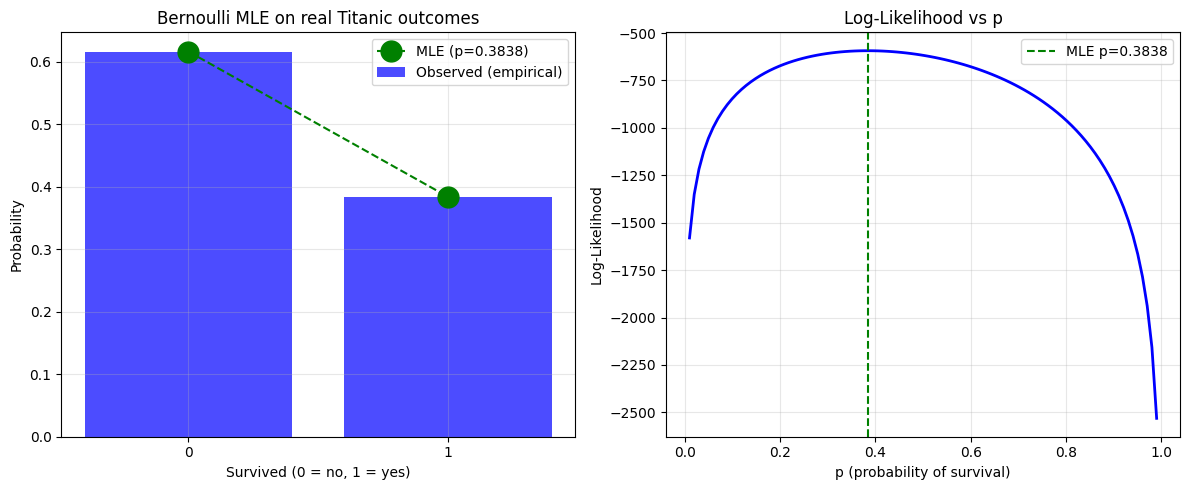


A single p treats every passenger alike. The real data does not:
  p_MLE for female passengers: 0.7420
  p_MLE for   male passengers: 0.1889
Fitting one Bernoulli PER GROUP is already a (very simple) classifier - and the
gap between these two numbers is why 'sex' is the single strongest Titanic feature.

✅ MLE for Bernoulli distribution implemented on real data!


In [4]:
# MLE for a Bernoulli on a REAL binary outcome: the observed success fraction maximizes
# the likelihood. This is the same math that calibrates a classifier's predicted probabilities.

print("\n" + "=" * 60)
print("Part 3: MLE for Bernoulli Distribution")
print("=" * 60)

# Real binary outcome: did each of the 891 passengers on the RMS Titanic survive?
titanic = pd.read_csv(data_path("titanic.csv"))
data_bernoulli = titanic["Survived"].to_numpy()

print(f"\nReal data: survival of {len(data_bernoulli)} Titanic passengers")
print(f" Number of survivors: {data_bernoulli.sum()}")
print(f" Number who died: {len(data_bernoulli) - data_bernoulli.sum()}")

# MLE for Bernoulli: sample proportion
mle_p = np.mean(data_bernoulli)

print(f"\nMLE estimate:")
print(f" p_MLE (sample proportion): {mle_p:.4f}  ->  a {mle_p:.1%} survival rate")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
unique, counts = np.unique(data_bernoulli, return_counts=True)
plt.bar(unique, counts / len(data_bernoulli), alpha=0.7, color='blue', label='Observed (empirical)')
x = np.array([0, 1])
plt.plot(x, stats.bernoulli.pmf(x, mle_p), 'go--', markersize=15, label=f'MLE (p={mle_p:.4f})')
plt.xlabel('Survived (0 = no, 1 = yes)')
plt.ylabel('Probability')
plt.title('Bernoulli MLE on real Titanic outcomes')
plt.xticks([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
p_range = np.linspace(0.01, 0.99, 100)
# Log-likelihood: k*log(p) + (n-k)*log(1-p) where k = sum(data)
k = data_bernoulli.sum()
n = len(data_bernoulli)
log_likelihoods = k * np.log(p_range) + (n - k) * np.log(1 - p_range)
plt.plot(p_range, log_likelihoods, 'b-', linewidth=2)
plt.axvline(mle_p, color='g', linestyle='--', label=f'MLE p={mle_p:.4f}')
plt.xlabel('p (probability of survival)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs p')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# One Bernoulli for everyone is the simplest possible model. Real survival was not uniform.
by_sex = titanic.groupby("Sex")["Survived"].mean()
print(f"\nA single p treats every passenger alike. The real data does not:")
for sex, rate in by_sex.items():
    print(f"  p_MLE for {sex:>6} passengers: {rate:.4f}")
print("Fitting one Bernoulli PER GROUP is already a (very simple) classifier - and the")
print("gap between these two numbers is why 'sex' is the single strongest Titanic feature.")

print("\n✅ MLE for Bernoulli distribution implemented on real data!")


## Summary

### Key Concepts:
1. **Likelihood Function**: Measures probability of observing data given parameters
2. **Maximum Likelihood Estimation**: Finds parameters that maximize likelihood
3. **Log-Likelihood**: Often easier to work with (converts products to sums)
4. **MLE for Common Distributions**:
   - Gaussian: sample mean and sample std
   - Poisson: sample mean
   - Bernoulli: sample proportion

### Best Practices:
- Use log-likelihood to avoid numerical underflow
- Verify constraints (e.g., σ > 0, 0 < p < 1)
- Compare MLE estimates with true parameters
- Understand when MLE is appropriate

### Applications:
- Parameter estimation
- Model fitting
- Statistical inference
- Machine learning (loss functions)

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Maximum Likelihood Estimation practical content

## 📚 References

1. Fisher, R. A. (1922). *On the Mathematical Foundations of Theoretical Statistics*. Philosophical Transactions of the Royal Society A, 222, 309–368.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 5: Machine Learning Basics (Maximum Likelihood Estimation). MIT Press. <https://www.deeplearningbook.org/>
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>